In [40]:
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

In [41]:

data = pd.read_csv('data/case1Data_preprocessed.csv')
X_test = pd.read_csv('data/case1Data_Xnew.csv')

X = data.drop(columns=["y"])
y = data["y"]

In [43]:
import numpy as np
import xgboost as xgb

from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import ElasticNetCV

alphas = []
l1_ratios = []
nonzero_counts = []

kf = KFold(n_splits=5, shuffle=True, random_state=42)

params = {
    "objective": "reg:squarederror",
    "eval_metric": "rmse",
    "learning_rate": 0.03,
    "max_depth": 3,
    "min_child_weight": 5,
    "subsample": 0.7,
    "colsample_bytree": 0.7,
    "lambda": 10.0,
    "alpha": 0.0,
    "tree_method": "hist",
    "seed": 42,
}

# storage
oof_xgb = np.zeros(len(X))
oof_en = np.zeros(len(X))

fold_rmses_xgb = []
fold_rmses_en = []

best_iters_xgb = []

for fold, (tr_idx, va_idx) in enumerate(kf.split(X), 1):

    X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
    y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]

    # =====================
    # XGBoost
    # =====================
    dtr = xgb.DMatrix(X_tr, label=y_tr)
    dva = xgb.DMatrix(X_va, label=y_va)

    booster = xgb.train(
        params,
        dtr,
        num_boost_round=5000,
        evals=[(dva, "val")],
        early_stopping_rounds=100,
        verbose_eval=False,
    )

    pred_xgb = booster.predict(
        dva, iteration_range=(0, booster.best_iteration + 1)
    )

    oof_xgb[va_idx] = pred_xgb
    rmse_xgb = np.sqrt(mean_squared_error(y_va, pred_xgb))
    fold_rmses_xgb.append(rmse_xgb)
    best_iters_xgb.append(booster.best_iteration)

    # =====================
    # Elastic Net
    # =====================
    model_en = ElasticNetCV(
        l1_ratio=[0.2, 0.5, 0.8, 0.9, 1.0],
        alphas=np.logspace(-4, 4, 100),
        cv=5,
        max_iter=10000
    )

    model_en.fit(X_tr, y_tr)

    alphas.append(model_en.alpha_)
    l1_ratios.append(model_en.l1_ratio_)

    nonzero = np.sum(np.abs(model_en.coef_) > 1e-6)
    nonzero_counts.append(nonzero)

    pred_en = model_en.predict(X_va)

    oof_en[va_idx] = pred_en
    rmse_en = np.sqrt(mean_squared_error(y_va, pred_en))
    fold_rmses_en.append(rmse_en)

    print(
        f"Fold {fold}: "
        f"xgboost={rmse_xgb:.2f}, "
        f"elastic={rmse_en:.2f}"
    )

# -----------------------------
# Results
# -----------------------------
rmse_xgb = np.sqrt(mean_squared_error(y, oof_xgb))
rmse_en = np.sqrt(mean_squared_error(y, oof_en))

print("\n--- XGBOOST ---")
print("Fold RMSEs:", [float(x) for x in fold_rmses_xgb])
print("OOF RMSE:", rmse_xgb)
print("Fold RMSE std:", np.std(fold_rmses_xgb))
print("Best iters:", best_iters_xgb, "median:", int(np.median(best_iters_xgb)))

print("\n--- ELASTIC NET ---")
print("Fold RMSEs:", [float(x) for x in fold_rmses_en])
print("OOF RMSE:", rmse_en)
print("Fold RMSE std:", np.std(fold_rmses_en))

print("\nElasticNet alphas:", alphas)
print("ElasticNet l1_ratios:", l1_ratios)
print("ElasticNet nonzero coefficients:", nonzero_counts)
print("Mean nonzero:", np.mean(nonzero_counts))

Fold 1: xgboost=48.87, elastic=32.85
Fold 2: xgboost=39.61, elastic=33.43
Fold 3: xgboost=29.17, elastic=33.83
Fold 4: xgboost=47.68, elastic=34.21
Fold 5: xgboost=53.84, elastic=38.51

--- XGBOOST ---
Fold RMSEs: [48.869085620517225, 39.60796750287428, 29.167756553569262, 47.68446275485046, 53.83993369354345]
OOF RMSE: 44.67724944489387
Fold RMSE std: 8.640079942717032
Best iters: [764, 2072, 4998, 857, 575] median: 857

--- ELASTIC NET ---
Fold RMSEs: [32.847252252553446, 33.428453904419555, 33.8332409395819, 34.209245432090434, 38.50957428224175]
OOF RMSE: 34.62470646197907
Fold RMSE std: 2.0230715124979586

ElasticNet alphas: [np.float64(1.3219411484660315), np.float64(0.521400828799969), np.float64(0.9111627561154896), np.float64(2.310129700083163), np.float64(4.862601580065354)]
ElasticNet l1_ratios: [np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0)]
ElasticNet nonzero coefficients: [np.int64(51), np.int64(62), np.int64(60), np.int64(43), np.int

In [47]:
import numpy as np

from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import ElasticNetCV, ElasticNet

kf = KFold(n_splits=5, shuffle=True, random_state=42)

# -----------------------------
# Storage
# -----------------------------
oof_min = np.zeros(len(X))
oof_1se = np.zeros(len(X))

fold_rmses_min = []
fold_rmses_1se = []

alphas_min = []
alphas_1se = []

l1_ratios_min = []
l1_ratios_1se = []

nonzero_min = []
nonzero_1se = []


def choose_one_se_model(cv_model):
    """
    Apply the one-standard-error rule to a fitted ElasticNetCV model.
    Returns:
        chosen_alpha, chosen_l1_ratio
    """
    mse_path = cv_model.mse_path_
    l1_grid = np.atleast_1d(cv_model.l1_ratio)

    # Make shape consistent: (n_l1_ratio, n_alpha, n_folds)
    if mse_path.ndim == 2:
        mse_path = mse_path[np.newaxis, :, :]

    alphas_grid = cv_model.alphas_
    if np.ndim(alphas_grid) == 1:
        alphas_grid = np.tile(alphas_grid, (len(l1_grid), 1))

    mean_mse = mse_path.mean(axis=2)
    se_mse = mse_path.std(axis=2, ddof=1) / np.sqrt(mse_path.shape[2])

    # Global minimum
    best_idx = np.unravel_index(np.argmin(mean_mse), mean_mse.shape)
    best_l1_idx, best_alpha_idx = best_idx

    min_mse = mean_mse[best_l1_idx, best_alpha_idx]
    se_at_min = se_mse[best_l1_idx, best_alpha_idx]
    threshold = min_mse + se_at_min

    # Candidates within 1 SE
    candidates = []
    for i in range(mean_mse.shape[0]):
        for j in range(mean_mse.shape[1]):
            if mean_mse[i, j] <= threshold:
                candidates.append((alphas_grid[i, j], l1_grid[i]))

    # Pick largest alpha = simplest model
    chosen_alpha, chosen_l1 = max(candidates, key=lambda t: t[0])

    return chosen_alpha, chosen_l1


for fold, (tr_idx, va_idx) in enumerate(kf.split(X), 1):

    X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
    y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]

    # -----------------------------
    # Inner CV
    # -----------------------------
    cv_model = ElasticNetCV(
        l1_ratio=[0.2, 0.5, 0.8, 0.9, 1.0],
        alphas=np.logspace(-4, 4, 100),
        cv=5,
        max_iter=10000
    )
    cv_model.fit(X_tr, y_tr)

    # ----- Minimum-CV choice
    alpha_min = cv_model.alpha_
    l1_min = cv_model.l1_ratio_

    model_min = ElasticNet(
        alpha=alpha_min,
        l1_ratio=l1_min,
        max_iter=10000
    )
    model_min.fit(X_tr, y_tr)

    pred_min = model_min.predict(X_va)
    rmse_min = np.sqrt(mean_squared_error(y_va, pred_min))

    oof_min[va_idx] = pred_min
    fold_rmses_min.append(rmse_min)
    alphas_min.append(alpha_min)
    l1_ratios_min.append(l1_min)
    nonzero_min.append(np.sum(np.abs(model_min.coef_) > 1e-6))

    # ----- One-SE choice
    alpha_1se, l1_1se = choose_one_se_model(cv_model)

    model_1se = ElasticNet(
        alpha=alpha_1se,
        l1_ratio=l1_1se,
        max_iter=10000
    )
    model_1se.fit(X_tr, y_tr)

    pred_1se = model_1se.predict(X_va)
    rmse_1se = np.sqrt(mean_squared_error(y_va, pred_1se))

    oof_1se[va_idx] = pred_1se
    fold_rmses_1se.append(rmse_1se)
    alphas_1se.append(alpha_1se)
    l1_ratios_1se.append(l1_1se)
    nonzero_1se.append(np.sum(np.abs(model_1se.coef_) > 1e-6))

    print(
        f"Fold {fold}: "
        f"minMSE RMSE={rmse_min:.2f}, alpha={alpha_min:.4g}, nonzero={nonzero_min[-1]} | "
        f"1SE RMSE={rmse_1se:.2f}, alpha={alpha_1se:.4g}, nonzero={nonzero_1se[-1]}"
    )

# -----------------------------
# Overall results
# -----------------------------
rmse_min_overall = np.sqrt(mean_squared_error(y, oof_min))
rmse_1se_overall = np.sqrt(mean_squared_error(y, oof_1se))

print("\n--- MINIMUM-CV MODEL ---")
print("Fold RMSEs:", [float(x) for x in fold_rmses_min])
print("OOF RMSE:", rmse_min_overall)
print("Fold RMSE std:", np.std(fold_rmses_min))
print("Chosen alphas:", alphas_min)
print("Chosen l1_ratios:", l1_ratios_min)
print("Nonzero coefficients:", nonzero_min)
print("Mean nonzero:", np.mean(nonzero_min))
print("Median alpha:", float(np.median(alphas_min)))

print("\n--- ONE-SE MODEL ---")
print("Fold RMSEs:", [float(x) for x in fold_rmses_1se])
print("OOF RMSE:", rmse_1se_overall)
print("Fold RMSE std:", np.std(fold_rmses_1se))
print("Chosen alphas:", alphas_1se)
print("Chosen l1_ratios:", l1_ratios_1se)
print("Nonzero coefficients:", nonzero_1se)
print("Mean nonzero:", np.mean(nonzero_1se))
print("Median alpha:", float(np.median(alphas_1se)))

print("\n--- DIFFERENCE: ONE-SE minus MINIMUM-CV ---")
print("OOF RMSE difference:", rmse_1se_overall - rmse_min_overall)
print("Median alpha difference:", float(np.median(alphas_1se) - np.median(alphas_min)))
print("Mean nonzero difference:", float(np.mean(nonzero_1se) - np.mean(nonzero_min)))

Fold 1: minMSE RMSE=32.85, alpha=1.322, nonzero=51 | 1SE RMSE=37.23, alpha=3.352, nonzero=35
Fold 2: minMSE RMSE=33.43, alpha=0.5214, nonzero=62 | 1SE RMSE=30.76, alpha=17.89, nonzero=9
Fold 3: minMSE RMSE=33.83, alpha=0.9112, nonzero=60 | 1SE RMSE=24.89, alpha=17.89, nonzero=13
Fold 4: minMSE RMSE=34.21, alpha=2.31, nonzero=43 | 1SE RMSE=33.35, alpha=4.037, nonzero=36
Fold 5: minMSE RMSE=38.51, alpha=4.863, nonzero=35 | 1SE RMSE=38.76, alpha=14.85, nonzero=13

--- MINIMUM-CV MODEL ---
Fold RMSEs: [32.847252252553446, 33.428453904419555, 33.8332409395819, 34.209245432090434, 38.50957428224175]
OOF RMSE: 34.62470646197907
Fold RMSE std: 2.0230715124979586
Chosen alphas: [np.float64(1.3219411484660315), np.float64(0.521400828799969), np.float64(0.9111627561154896), np.float64(2.310129700083163), np.float64(4.862601580065354)]
Chosen l1_ratios: [np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0)]
Nonzero coefficients: [np.int64(51), np.int64(62), np.int64(

C:\Users\Jacob pc\AppData\Roaming\Python\Python312\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.672e+02, tolerance: 4.994e+02
  model = cd_fast.enet_coordinate_descent(
C:\Users\Jacob pc\AppData\Roaming\Python\Python312\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.859e+03, tolerance: 4.994e+02
  model = cd_fast.enet_coordinate_descent(
C:\Users\Jacob pc\AppData\Roaming\Python\Python312\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or co

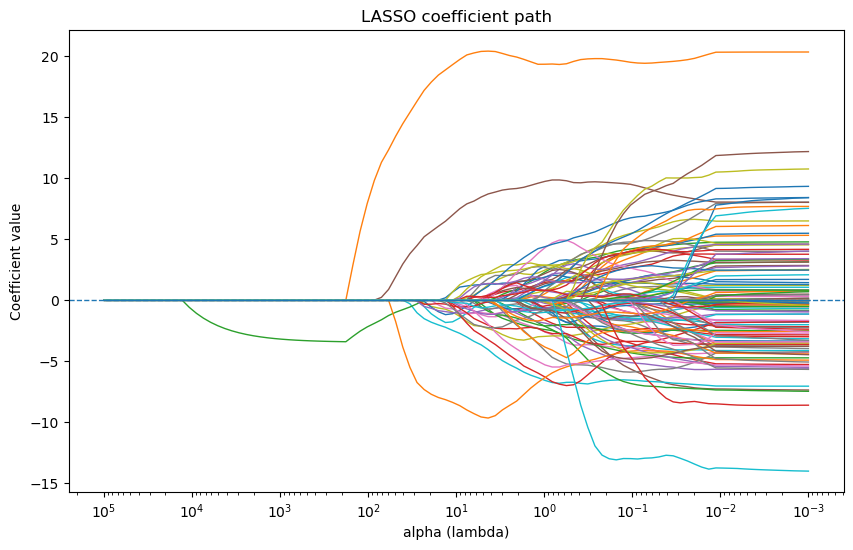

In [44]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import lasso_path

# -----------------------------
# Prepare X for LASSO
# -----------------------------
X_plot = X.values
y_plot = y.values

feature_names = X.columns

# -----------------------------
# Compute LASSO path
# -----------------------------
alphas_lasso = np.logspace(-3, 5, 100)

alphas_path, coefs_path, _ = lasso_path(
    X_plot,
    y_plot,
    alphas=alphas_lasso
)

# -----------------------------
# Plot coefficient paths
# -----------------------------
plt.figure(figsize=(10, 6))

for i in range(coefs_path.shape[0]):
    plt.plot(alphas_path, coefs_path[i], linewidth=1)

plt.xscale("log")
plt.gca().invert_xaxis()   # large alpha on left, small alpha on right
plt.xlabel("alpha (lambda)")
plt.ylabel("Coefficient value")
plt.title("LASSO coefficient path")
plt.axhline(0, linestyle="--", linewidth=1)

plt.show()